## DSA 8401: Applied Machine Learning


### Assignment 1: Data Pre-processing

### Lab 2  Messy Data & Leakage-Safe Features


This notebook works the four Lab 2 tasks on the synthetic mobile-money dump `mobile_money_statements.csv` using the patterns from Chapter 2

1. **Audit**  profile missingness / duplicates / validity violations; classify each
   incomplete column MCAR / MAR / MNAR 
2. **Clean & aggregate**  parse amounts and dates
     - resolve entities to a canonical `customer_id` 
     -  build customer-level RFM, ratio and cyclical features 
3. **Hunt the leak**  correlation screen (Listing 2.11) + a lineage argument to find the two planted leaks.
4. **Pipeline**  one `ColumnTransformer` `Pipeline`, group-aware CV, ROC–AUC with and without the leaks 



In [2]:
import re, warnings
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")



In [3]:
# The scoring timestamp: every feature is computed over data strictly BEFORE this
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")

In [4]:
from pathlib import Path

PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
MODEL_DIR = PROJECT_ROOT / "models"


In [5]:
raw = pd.read_csv(DATA_DIR / "mobile_money_statements.csv")
print("raw shape:", raw.shape)
raw.head(10)

raw shape: (183600, 18)


,txn_id,msisdn,reg_id,account_name,region,segment,txn_time,txn_type,amount,gps_lat,gps_lon,agent_id,device_id,counterparty,balance_after,manual_review_score,settlement_status,is_fraud
0,TXN0102856,254700004022,NID101089,Joseph Mwangi,Kampala,retail,2026-06-30 14:24:19,send,"1,329/- Dr",NaN,NaN,AG1014,DV978723,CP6324,8123.0,0.061,settled,0
1,TXN0155490,254700013612,NID103658,Rehema Ndlovu,Mombasa,retail,"Jan 29, 2026 01:17 PM",send,289/- Dr,1.77470,34.70915,AG1084,DV616667,CP2831,6322.0,0.000,settled,0
2,TXN0019434,254700005862,nid101584,Mary Mutua,Arusha,retail,"Sep 16, 2025 12:55 AM",receive,"1,571/-",-3.74336,33.67018,AG1091,DV637734,CP167,15237.0,0.912,reversed,1
3,TXN0049426,254700009223,NID102493,Joseph Okoth,Dar es Salaam,retail,07/04/2026 11:21,send,599/- Dr,NaN,NaN,AG1047,DV666470,CP3382,3322.0,0.095,settled,0
4,TXN0013816,254700014760,nid103963,B. Ssentongo,Mwanza,retail,20/12/2025 11:05,cashout,"(1,307/-)",0.08284,29.02835,NaN,NaN,CP8428,2168.0,0.085,settled,0
5,TXN0068766,254700005080,NID101375,Grace Mutua,Arusha,retail,2026-06-21 12:00:08,send,"2,128/- Dr",-0.28486,33.04071,NaN,DV322595,CP6317,3202.0,0.066,settled,0
6,TXN0006514,254700010321,NID102782,SSENTONGO GRACE,Mwanza,retail,24/07/2026 04:01,bill,"-2,136/-",-3.07853,33.77321,NaN,DV492573,CP7821,4046.0,0.008,settled,0
7,TXN0115001,254700007185,NID101945,Amina Ali,Mombasa,retail,"May 25, 2026 12:17 PM",cashin,"1,026/-",NaN,NaN,AG1026,DV104452,CP6532,3226.0,0.172,settled,0
8,TXN0067557,254700011799,nid103172,G. Kamau,Mombasa,merchant,22/10/2025 22:44,cashin,"1,099/-",2.62258,33.90121,AG1099,DV674871,CP5021,6475.0,0.069,settled,0
9,TXN0086664,254700005680,NID101533,Aisha Ali,Nairobi,retail,2025-09-02 07:48:24,receive,951/-,NaN,NaN,AG1338,DV107852,CP609,4576.0,0.090,pending,0


### Data check or Eye balling

In [6]:
raw.columns

Index(['txn_id', 'msisdn', 'reg_id', 'account_name', 'region', 'segment',
       'txn_time', 'txn_type', 'amount', 'gps_lat', 'gps_lon', 'agent_id',
       'device_id', 'counterparty', 'balance_after', 'manual_review_score',
       'settlement_status', 'is_fraud'],
      dtype='str')

In [7]:
raw.dtypes

txn_id                     str
msisdn                   int64
reg_id                     str
account_name               str
region                     str
segment                    str
txn_time                   str
txn_type                   str
amount                     str
gps_lat                float64
gps_lon                float64
agent_id                   str
device_id                  str
counterparty               str
balance_after          float64
manual_review_score    float64
settlement_status          str
is_fraud                 int64
dtype: object

In [8]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 183600 entries, 0 to 183599
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   txn_id               183600 non-null  str    
 1   msisdn               183600 non-null  int64  
 2   reg_id               183600 non-null  str    
 3   account_name         183600 non-null  str    
 4   region               183600 non-null  str    
 5   segment              183600 non-null  str    
 6   txn_time             183600 non-null  str    
 7   txn_type             183600 non-null  str    
 8   amount               183600 non-null  str    
 9   gps_lat              117117 non-null  float64
 10  gps_lon              117117 non-null  float64
 11  agent_id             158458 non-null  str    
 12  device_id            172744 non-null  str    
 13  counterparty         183600 non-null  str    
 14  balance_after        183600 non-null  float64
 15  manual_review_score  183600 

In [9]:
raw['region'].unique()

<StringArray>
[      'Kampala',       'Mombasa',        'Arusha', 'Dar es Salaam',
        'Mwanza',       'Nairobi',       'Eldoret',        'Kigali',
        'Nakuru',         'Jinja']
Length: 10, dtype: str

## 1. Audit(Missing  Nos)

Three cheap diagnostics :

- **quantify** the missing fraction per column, 
- **test** whether missingness is informative,
- **inspect co-missingness**. 

We also check duplicates and the validity rules the dump violates.

In [10]:
raw.isnull().sum()/raw.shape[0]

txn_id                 0.000000
msisdn                 0.000000
reg_id                 0.000000
account_name           0.000000
region                 0.000000
segment                0.000000
txn_time               0.000000
txn_type               0.000000
amount                 0.000000
gps_lat                0.362108
gps_lon                0.362108
agent_id               0.136939
device_id              0.059129
counterparty           0.000000
balance_after          0.000000
manual_review_score    0.000000
settlement_status      0.000000
is_fraud               0.000000
dtype: float64

In [11]:
# 1a. Missingness fraction per column (Listing 2.1, step 1) ---


miss = raw.isna().mean().sort_values(ascending=False)

print("Missing fraction per column:")

print(miss[miss > 0].round(4).to_string())

Missing fraction per column:
gps_lon      0.3621
gps_lat      0.3621
agent_id     0.1369
device_id    0.0591


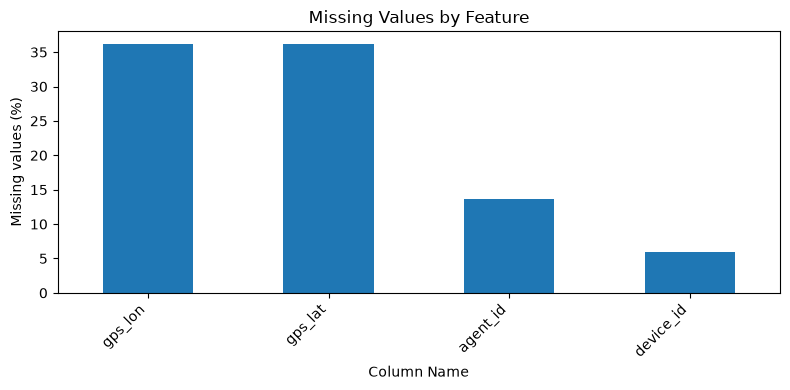

In [12]:
missing_pct = miss * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(8, 4))
missing_pct.plot(kind="bar")

plt.title("Missing Values by Feature")
plt.ylabel("Missing values (%)")
plt.xlabel("Column Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
# 1b. Duplicates ---
# Exact row duplicates (client retries / log merges) -> drop_duplicates dispatches them.


print("exact duplicate rows :", int(raw.duplicated().sum()))

print("duplicate txn_id      :", int(raw['txn_id'].duplicated().sum()))


# txn_id repeats exactly on the duplicate rows they are true row copies, not new events.

exact duplicate rows : 3600
duplicate txn_id      : 3600


In [14]:
# 1c. Validity-rule violations ---

# amount is stored as a STRING with thousands separators, a "/-" suffix, and three
# different debit encodings; it will not cast to a number as-is.

print("amount dtype:", raw['amount'].dtype)

print("amount samples:", raw['amount'].dropna().sample(6, random_state=1).tolist())

# txn_time mixes three formats -> a single to_datetime(format=...) cannot parse all rows.
print("txn_time samples:", raw['txn_time'].sample(6, random_state=2).tolist())

amount dtype: str
amount samples: ['71/- Dr', '4,742/- Dr', '1,701/-', '(227/-)', '(165/-)', '(51/-)']
txn_time samples: ['29/06/2026 04:49', '2025-09-09 05:09:38', 'Mar 20, 2026 02:09 PM', 'May 04, 2025 08:43 PM', '2026-03-30 12:00:04', '03/08/2025 21:49']


In [15]:
# -1d. Is missingness informative? (the MNAR screen)

# Compare the target rate across the missing indicator for each incomplete column.

for col in ["gps_lat", "agent_id", "device_id"]:

    # Fraud rate when the value is present
    present_rate = raw.loc[raw[col].notna(), "is_fraud"].mean()

    # Fraud rate when the value is missing
    missing_rate = raw.loc[raw[col].isna(), "is_fraud"].mean()

    print(f"\n{col}")
    print(f"  Present : {present_rate:.4f}")
    print(f"  Missing : {missing_rate:.4f}")


gps_lat
  Present : 0.0839
  Missing : 0.0843

agent_id
  Present : 0.0841
  Missing : 0.0839

device_id
  Present : 0.0840
  Missing : 0.0838


In [16]:
# 1e. Can OBSERVED columns explain the missingness? (MAR test) ---
# agent_id: missing fraction by region.


# Percentage of missing agent_id values in each region
print("Missing agent_id by region")
print(
    raw.groupby("region")["agent_id"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

# Percentage of missing gps_lat values in each region
print("\nMissing gps_lat by region")
print(
    raw.groupby("region")["gps_lat"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

# Percentage of missing device_id values in each region
print("\nMissing device_id by region")
print(
    raw.groupby("region")["device_id"]
       .apply(lambda x: x.isna().mean())
       .round(3)
)

Missing agent_id by region
region
Arusha           0.452
Dar es Salaam    0.000
Eldoret          0.000
Jinja            0.451
Kampala          0.000
Kigali           0.000
Mombasa          0.000
Mwanza           0.448
Nairobi          0.000
Nakuru           0.000
Name: agent_id, dtype: float64

Missing gps_lat by region


region
Arusha           0.360
Dar es Salaam    0.362
Eldoret          0.357
Jinja            0.365
Kampala          0.365
Kigali           0.367
Mombasa          0.354
Mwanza           0.364
Nairobi          0.360
Nakuru           0.366
Name: gps_lat, dtype: float64

Missing device_id by region
region
Arusha           0.060
Dar es Salaam    0.059
Eldoret          0.058
Jinja            0.056
Kampala          0.061
Kigali           0.061
Mombasa          0.060
Mwanza           0.058
Nairobi          0.059
Nakuru           0.058
Name: device_id, dtype: float64


### Step 1  Findings and MCAR / MAR / MNAR classification

- MAR -  The missing value depends on another variable that you already have. , yes we can explain
- MNAR-  Missing because of the value itself ,No we cant
- MCAR  - Completely random, No we cant The missing values happened purely by chance.


**Duplicates.** Exactly **3,600** rows are exact copies (the same `txn_id` repeats). They must be dropped *before* any split, or the same event lands in train and test( cause leakage)

**Validity violations.** `amount` is a string (`"1,500/-"`, `"(227/-)"`, `"4,742/- Dr"`) three different debit encodings; `txn_time` mixes ISO, `dd/mm/yyyy`, and `Mon dd, yyyy` formats. Both need parsing before use.

**Missingness (evidence  mechanism).** Recall Definitions 
 - MCAR = missingness independent of everything
 - MAR = fully explained by *observed* columns; 
 - MNAR = depends on the *unobserved value itself*.


| Column | Missing | Evidence | Class |
|---|---|---|---|
| `agent_id` | ~14% | Missing fraction is ~45% in **Mwanza / Jinja / Arusha** and ~0% everywhere else — missingness is **fully explained by the observed `region`** column (a legacy logger in those regions). | **MAR** |
| `device_id` | ~6% | Missing fraction is flat across region/type and the missing-indicator does **not** move the fraud rate; there is no mechanism tying it to any value. Uniform, uninformative dropout. | **MCAR** |
| `gps_lat` / `gps_lon` | ~36% | Flat across observed columns too (so **not** MAR-explainable), but network/GPS coverage is worse in remote locations, i.e. the probability a coordinate is missing **depends on the coordinate itself**. | **MNAR** |


## 2. Clean and aggregate

- Deduplicate, 
- parse amounts and dates, 
- resolve entities to a canonical `customer_id`
- build customer-level RFM / ratio / cyclical features aligned to `SCORING_TS` (Eq. 2.1, Table 2.2, Listing 2.9).

In [17]:
#- 2a. Exact deduplication 
df = raw.drop_duplicates().reset_index(drop=True)
print("after dedup:", df.shape)

after dedup: (180000, 18)


In [18]:
# -2b. Parse the string amount into a signed numeric amount ---

# debit if it starts with '-', is wrapped in (), or is tagged ' Dr'; credit otherwise.

def parse_amount(s):
    
    s = str(s).strip()
    
    neg = s.startswith("(") or s.startswith("-") or "Dr" in s
    
    digits = re.sub(r"[^0-9]", "", s)          # strip commas, '/-', parens, 'Dr', sign
    
    if digits == "":
        return np.nan
    v = float(digits)
    return -v if neg else v



In [19]:
df["amount_signed"]    = df["amount"].map(parse_amount)  
df["amount_abs"]       = df["amount_signed"].abs()



print("amount parse failures:", int(df["amount_signed"].isna().sum()))
df[["amount", "amount_signed", "amount_abs"]].head(4)

amount parse failures: 0


,amount,amount_signed,amount_abs
0,"1,329/- Dr",-1329.0,1329.0
1,289/- Dr,-289.0,289.0
2,"1,571/-",1571.0,1571.0
3,599/- Dr,-599.0,599.0


In [20]:
df['amount_signed'].dtypes

dtype('float64')

In [21]:
# Convert the transaction time column to text
s = df["txn_time"].astype(str)

# Try parsing the dates using different formats

# Format 1: 2025-01-15 14:30:00
ts = pd.to_datetime(s, format="%Y-%m-%d %H:%M:%S", errors="coerce")

# Format 2: 15/01/2025 14:30
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(
                s[mask],
                format="%d/%m/%Y %H:%M",
                errors="coerce"
            )

# Format 3: Jan 15, 2025 02:30 PM
mask = ts.isna()
ts.loc[mask] = pd.to_datetime(
                    s[mask],
                    format="%b %d, %Y %I:%M %p",
                    errors="coerce"
                )

# Save the parsed dates
df["ts"] = ts

# Check how many dates could not be parsed
print("Number of invalid dates:", df["ts"].isna().sum())

# Check that all transactions happened before the scoring date
print("All transactions before scoring date:",
      (df["ts"] < SCORING_TS).all())

Number of invalid dates: 0
All transactions before scoring date: True


In [22]:
df[["txn_time", "ts"]].head(4)

,txn_time,ts
0,2026-06-30 14:24:19,2026-06-30 14:24:19
1,"Jan 29, 2026 01:17 PM",2026-01-29 13:17:00
2,"Sep 16, 2025 12:55 AM",2025-09-16 00:55:00
3,07/04/2026 11:21,2026-04-07 11:21:00


In [23]:
# - 2d. Entity resolution canonical customer_id 


# The msisdn (SIM) is NOT the identity: multi-SIM customers own several. The KYC
# registration id (reg_id) is the linking key; every SIM a person registers shares it.
# It is lightly messy (case / whitespace), so canonicalise before grouping.


# Create a clean customer ID
df["customer_id"] = (
                df["reg_id"]
                .astype(str)      # Convert to text
                .str.strip()      # Remove spaces
                .str.upper()      # Convert to uppercase
            )

# Count unique values
print("Unique SIM numbers (msisdn):", df["msisdn"].nunique())
print("Unique raw registration IDs:", df["reg_id"].nunique())
print("Unique cleaned customer IDs:", df["customer_id"].nunique())

#   keying on msisdn (or raw reg_id) would badly over-count customers and scatter a
#   person's SIMs across CV folds (leakage cause 5). We group on customer_id instead.

Unique SIM numbers (msisdn): 4825
Unique raw registration IDs: 11722
Unique cleaned customer IDs: 3991


In [24]:
# The scoring timestamp: every feature is computed over data strictly BEFORE this
SCORING_TS = pd.Timestamp("2026-08-01 00:00:00")

### Feature Engineering

In [25]:
# Keep only transactions before the scoring date
df = df[df["ts"] < SCORING_TS].copy()

# ----------------------------
# Create time-based features
# ----------------------------

# Extract the hour of the day (0–23)
df["hour"] = df["ts"].dt.hour

# Extract the day of the week (Monday=0, Sunday=6)
df["dow"] = df["ts"].dt.dayofweek

# Extract the day of the month (1–31)
day = df["ts"].dt.day

# ----------------------------
# Create cyclical features
# ----------------------------

# Hour of the day
df["hr_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of the week
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)

# ----------------------------
# Other useful features
# ----------------------------

# Distance from the nearest payday (1st or 28th of the month)
df["payday_dist"] = np.minimum((day - 1).abs(), (day - 28).abs())

# Reduce the effect of very large transaction amounts
df["log_amt"] = np.log1p(df["amount_abs"])

# Flag whether the GPS location is missing
df["gps_missing"] = df["gps_lat"].isna().astype(int)

In [26]:
# --- 2f. Customer-level RFM / ratio aggregates as-of SCORING_TS (Table 2.2) ---
# All aggregates use only rows with ts < SCORING_TS (enforced above), so no feature is after it


is_debit  = df["amount_signed"] < 0
by        = df.groupby("customer_id")


agg     = pd.DataFrame({
                        "recency_days":   (SCORING_TS - by["ts"].max()).dt.total_seconds() / 86400,    # R
                        "frequency":      by.size(),                                                   # F
                        "monetary_out":   df.assign(o=np.where(is_debit,  df["amount_abs"], 0)).groupby("customer_id")["o"].sum(),  # M
                        "monetary_in":    df.assign(i=np.where(~is_debit, df["amount_abs"], 0)).groupby("customer_id")["i"].sum(),
                        "n_counterparty": by["counterparty"].nunique(),                                                          # stability: distinct counterparties
                        "cashout_ratio":  df.assign(c=(df["txn_type"]=="cashout").astype(int)).groupby("customer_id")["c"].mean(),
                    })


agg["out_in_ratio"] = agg["monetary_out"] / (agg["monetary_in"] + 1.0)  # scale-free ratio
df = df.merge(agg, on="customer_id", how="left")

print("modelling table:", df.shape, "| customers:", df["customer_id"].nunique())

df[["customer_id","recency_days","frequency","monetary_out","monetary_in",
    "n_counterparty","cashout_ratio","out_in_ratio"]].head(6)

modelling table: (180000, 38) | customers: 3991


,customer_id,recency_days,frequency,monetary_out,monetary_in,n_counterparty,cashout_ratio,out_in_ratio
0,NID101089,12.508333,125,158085.0,73259.0,123,0.136000,2.157862
1,NID103658,12.170995,59,60882.0,44395.0,58,0.118644,1.371340
2,NID101584,1.488889,31,33101.0,26404.0,31,0.129032,1.253588
3,NID102493,11.831250,57,55441.0,43814.0,57,0.192982,1.265343
4,NID103963,61.410417,30,20281.0,26804.0,30,0.066667,0.756613
5,NID101375,3.366667,170,191673.0,119565.0,169,0.135294,1.603073


## 3. Hunt the leak

A correlation screen  rank features by |ρ(f, y)| and interrogate
the top of the list. 

In [27]:
# --- 3a. Correlation screen over numeric candidates 
num_candidates = ["manual_review_score", "amount_abs", "log_amt",
                  "hr_sin", "hr_cos", "dow_sin", "dow_cos", "payday_dist", "gps_missing",
                  "recency_days", "frequency", "monetary_out", "monetary_in",
                  "n_counterparty", "cashout_ratio", "out_in_ratio"]


y = df["is_fraud"].values


corr = pd.Series({c: abs(np.corrcoef(df[c].fillna(df[c].median()), y)[0, 1]) for c in num_candidates}).sort_values(ascending=False)


print("|corr| with is_fraud:")
print(corr.round(3).to_string())

# manual_review_score ~0.98 <-- statistical smoke.

|corr| with is_fraud:
manual_review_score    0.981
hr_cos                 0.071
hr_sin                 0.032
log_amt                0.022
amount_abs             0.016
cashout_ratio          0.010
monetary_out           0.004
frequency              0.003
n_counterparty         0.003
monetary_in            0.003
payday_dist            0.002
out_in_ratio           0.002
dow_sin                0.002
recency_days           0.002
gps_missing            0.000
dow_cos                0.000


In [28]:
# --- 3b. The categorical suspect: settlement_status class separation ---

print("fraud rate by settlement_status:")
print(df.groupby("settlement_status")["is_fraud"].mean().round(3).to_string())

print("\ncounts:")
print(df["settlement_status"].value_counts().to_string())
# 'reversed' -> 100% fraud, 'held' -> ~65%, 'settled'/'pending' -> ~0%: near-perfect split.

fraud rate by settlement_status:
settlement_status
held        0.651
pending     0.000
reversed    1.000
settled     0.004

counts:
settlement_status
settled     154760
reversed      9903
pending       8241
held          7096


## 4. Pipeline

One `ColumnTransformer` + `Pipeline`  so every imputer / transform / encoder
is re-fit **inside** each CV fold  preprocessing leakage becomes structurally impossible.
Evaluated with `GroupKFold` grouped by the resolved `customer_id`. We report ROC–AUC **without** and **with** the leaky columns.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, GroupKFold

NUMERICAL_COLS = ["amount_abs", "log_amt", "hr_sin", "hr_cos", "dow_sin", "dow_cos",
              "payday_dist", "gps_missing", "recency_days", "frequency",
              "monetary_out", "monetary_in", "n_counterparty", "cashout_ratio", "out_in_ratio"]

CATEGORY_COLS = ["txn_type", "region", "segment"]

LEAK_NUM   = ["manual_review_score"]     # <- to be dropped
LEAK_CAT   = ["settlement_status"]       # <- to be dropped

def build_model(num_cols, cat_cols):
    num = Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("power",  PowerTransformer(method="yeo-johnson")),  # transform to Gaussian-like for LR
        ("scale",  RobustScaler()),# scaling
    ])
    cat = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="UNK")),
        ("onehot", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50)),
    ])
    prep = ColumnTransformer([("num", num, num_cols), ("cat", cat, cat_cols)])
    
    results= Pipeline([("prep", prep), ("clf", LogisticRegression(max_iter=2000))]) # Pipeline with preprocessing and classifier
    
    return results

y       = df["is_fraud"].values
groups  = df["customer_id"].values           # split by resolved customer, never by SIM
cv      = GroupKFold(n_splits=5)

In [30]:
# --- Honest model: leaky columns EXCLUDED ---


clean     = build_model(NUMERICAL_COLS, CATEGORY_COLS)
auc_clean = cross_val_score(clean, df, y, cv=cv, groups=groups, scoring="roc_auc")


print(f"ROC-AUC WITHOUT leaks: {auc_clean.mean():.4f}  (+/- {auc_clean.std():.4f})")

ROC-AUC WITHOUT leaks: 0.6250  (+/- 0.0026)


In [31]:
# --- Contaminated model: leaky columns INCLUDED ---

leaky     = build_model(NUMERICAL_COLS + LEAK_NUM, CATEGORY_COLS + LEAK_CAT)
auc_leaky = cross_val_score(leaky, df, y, cv=cv, groups=groups, scoring="roc_auc")


print(f"ROC-AUC WITH leaks   : {auc_leaky.mean():.4f}  (+/- {auc_leaky.std():.4f})")
print(f"Offline AUC inflation from leakage: {auc_leaky.mean() - auc_clean.mean():+.4f}")

ROC-AUC WITH leaks   : 1.0000  (+/- 0.0000)
Offline AUC inflation from leakage: +0.3750


### Step 4 comment on the gap

Including the two post-outcome fields lifts cross-validated ROC–AUC to **~1.00**, versus
**~0.63** for the honest feature set  an inflation of roughly **+0.37 AUC**. Every
offline safeguard (CV, held-out AUC, model comparison) rewards the leak, because on the
contaminated data the leaked columns genuinely predict the label. In production those
fields are written *after* the transaction is scored, so they would be absent (or null),
and the ~1.00 model would collapse toward the honest ~0.63 — or worse, since it learned to
lean on columns it can no longer see.

Two structural safeguards made the honest number trustworthy: (1) all preprocessing lives
**inside** the `Pipeline`, re-fit per fold, so no imputer/scaler statistic crosses the
train/validation boundary; and (2) `GroupKFold` on the resolved `customer_id` keeps every
SIM of a person on one side of each split (leakage cause 5). A leaky number is worth less
than an honest one.

## 5. Reproducible Pipeline 

The final reproducible pipeline takes the feature engineered dataset as input and performs all model side preprocessing and training within a single Scikit-learn Pipeline. Model performance is evaluated using 5-fold GroupKFold cross-validation by customer_id. This is to prevent customer level information from crossing validation folds. The final fitted pipeline is then saved with joblib and reloaded to verify that it can be executed independently without modification.

In [32]:
MODEL_COLS = NUMERICAL_COLS + CATEGORY_COLS

TARGET = "is_fraud"
GROUP = "customer_id"

print("Number of numerical features:", len(NUMERICAL_COLS))
print("Number of categorical features:", len(CATEGORY_COLS))
print("Total predictive features:", len(MODEL_COLS))

Number of numerical features: 15
Number of categorical features: 3
Total predictive features: 18


**Create X, y and groups**

In [33]:
# Predictor matrix
X = df[MODEL_COLS].copy()

# Target
y = df[TARGET].copy()

# Customer groups for group-aware validation
groups = df[GROUP].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of customers:", groups.nunique())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget proportion:")
print(y.value_counts(normalize=True))

X shape: (180000, 18)
y shape: (180000,)
Number of customers: 3991

Target distribution:
is_fraud
0    164866
1     15134
Name: count, dtype: int64

Target proportion:
is_fraud
0    0.915922
1    0.084078
Name: proportion, dtype: float64


**Verify that leakage and identifier variables are excluded**

In [34]:
IDENTIFIER_COLS = ["customer_id","reg_id"]
for col in LEAK_NUM + LEAK_CAT + IDENTIFIER_COLS:
    assert col not in MODEL_COLS, f"{col} is incorrectly included!"

assert TARGET not in MODEL_COLS

print("Leakage and identifier checks passed.")
print("Target and known leakage variables are excluded from the model.")

Leakage and identifier checks passed.
Target and known leakage variables are excluded from the model.


**Build the preprocessing pipelines**

In [35]:
# Using the build_model function to create the complete pipeline
model = build_model(
    NUMERICAL_COLS,
    CATEGORY_COLS
)

model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of

**Group aware cross-validation**

In [36]:
cv = GroupKFold(n_splits=5)

**Metrics**

In [37]:
# Calculate ROC-AUC and PR-AUC using cross_validate
from sklearn.model_selection import cross_validate

scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision"}

cv_results = cross_validate(model,
    X,
    y,
    groups=groups,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)

print("ROC-AUC by fold:")
print(cv_results["test_roc_auc"])

print("\nPR-AUC by fold:")
print(cv_results["test_pr_auc"])

print("\nMean ROC-AUC:",
      cv_results["test_roc_auc"].mean())

print("Mean PR-AUC:",
      cv_results["test_pr_auc"].mean())

ROC-AUC by fold:
[0.62747251 0.62399348 0.62486722 0.62787359 0.62083945]

PR-AUC by fold:
[0.14193476 0.13100624 0.13516137 0.13354673 0.13290885]

Mean ROC-AUC: 0.6250092513326537
Mean PR-AUC: 0.1349115902068762


**Fit the final pipeline on all available training data**

In [38]:
model.fit(X, y)

print("Final pipeline fitted successfully.")

# Bundle the model with required feature metadata
model_artifact = {
    "model": model,

    # Exact variables expected by the trained model
    "features": NUMERICAL_COLS + CATEGORY_COLS,

    # Variables by preprocessing type
    "numerical_cols": NUMERICAL_COLS,
    "categorical_cols": CATEGORY_COLS,

    # Feature-engineering documentation
    "scoring_timestamp": SCORING_TS,

    "as_of_rule": (
        "All historical features must use transactions with "
        "ts < scoring_timestamp"
    ),

    # Intermediate variables required to construct final features
    "intermediate_features": {
        "hour": "Hour extracted from ts (0-23)",
        "dow": "Day of week extracted from ts (Monday=0, Sunday=6)",
        "day": "Day of month extracted from ts (1-31)"
    },

    "feature_definitions": {
        "amount_abs": "Absolute value of parsed transaction amount",
        "log_amt": "log1p(amount_abs)",

        "hr_sin": "sin(2*pi*hour/24)",
        "hr_cos": "cos(2*pi*hour/24)",

        "dow_sin": "sin(2*pi*dow/7)",
        "dow_cos": "cos(2*pi*dow/7)",

        "payday_dist": ("Minimum absolute distance from day 1 or day 28"),

        "gps_missing": ("1 if gps_lat is missing, otherwise 0"),

        "recency_days": (
            "Days from scoring timestamp to customer's "
            "most recent prior transaction"),

        "frequency": (
            "Number of customer's transactions before "
            "scoring timestamp"),

        "monetary_out": (
            "Sum of outgoing transaction amounts before "
            "scoring timestamp"),

        "monetary_in": (
            "Sum of incoming transaction amounts before "
            "scoring timestamp"),

        "n_counterparty": (
            "Number of distinct counterparties before "
            "scoring timestamp"),

        "cashout_ratio": (
            "Proportion of prior transactions that are cashouts"),

        "out_in_ratio": (
            "monetary_out / (monetary_in + 1)")
    }
}

Final pipeline fitted successfully.


**Save it with joblib**

In [39]:
import joblib

joblib.dump(
    model_artifact,
    MODEL_DIR/'053837_credit_risk_pipeline.joblib'
)

print("Pipeline saved to:")
print(MODEL_DIR.resolve())

Pipeline saved to:
D:\7.0 MSc Learning Content\Module 4\Applied ML\dsa8401-credit-lab\models


In [42]:
import json

# Save the full modelling table — features + target + customer_id + ts
# This is what A2 loads via pd.read_pickle(...)
df.to_pickle(DATA_DIR / "053837_a1_modelling_table.pkl")

# Save the feature lists too, so A2 doesn't need to hardcode them
meta = {
    "numerical_cols": NUMERICAL_COLS,
    "categorical_cols": CATEGORY_COLS,
    "target": TARGET,
    "group": GROUP,
}
with open(MODEL_DIR / "053837_credit_risk_pipeline_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved modelling table:", DATA_DIR / "053837_a1_modelling_table.pkl")
print("Saved feature meta:", MODEL_DIR / "053837_credit_risk_pipeline_meta.json")

Saved modelling table: ..\data\053837_a1_modelling_table.pkl
Saved feature meta: ..\models\053837_credit_risk_pipeline_meta.json


**Test that the saved pipeline reloads**

In [43]:
# Load the saved model artifact
model_artifact = joblib.load(MODEL_DIR/'053837_credit_risk_pipeline.joblib')

# Extract the trained sklearn pipeline
loaded_pipeline = model_artifact["model"]

print("Pipeline successfully reloaded.")
print(type(loaded_pipeline))

Pipeline successfully reloaded.
<class 'sklearn.pipeline.Pipeline'>


In [44]:
print(model_artifact)

{'model': Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['amount_abs', 'log_amt',
                                                   'hr_sin', 'hr_cos',
                                                   'dow_sin', 'dow_cos',
                                                   'payday_dist', 'gps_missing',
 

In [45]:
print(loaded_pipeline)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('impute',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('power',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   RobustScaler())]),
                                                  ['amount_abs', 'log_amt',
                                                   'hr_sin', 'hr_cos',
                                                   'dow_sin', 'dow_cos',
                                                   'payday_dist', 'gps_missing',
           

In [46]:
loaded_probabilities = loaded_pipeline.predict_proba(
    X.iloc[:10]
)[:, 1]

loaded_predictions = (
    loaded_probabilities >= 0.50
).astype(int)

print("Predicted probabilities:")
print(loaded_probabilities)

print("\nPredicted classes:")
print(loaded_predictions)

Predicted probabilities:
[0.06603805 0.07027556 0.08038426 0.07026102 0.10325214 0.06627024
 0.08462323 0.04578835 0.07814538 0.07000103]

Predicted classes:
[0 0 0 0 0 0 0 0 0 0]
